# Train BiLSTM Retriever

Train a BiLSTM bi-encoder on MS MARCO (query, passage) pairs using InfoNCE contrastive loss.


In [ ]:
import json
import random
import sys
import time
from pathlib import Path

import mlflow
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Add project root to path so we can import src/
ROOT = Path(".").resolve()
if "notebooks" in str(ROOT):
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.infonce_loss import infonce_loss
from src.lstm_encoder import LSTMEncoder
from src.tfidf_retrieval import load_jsonl
from src.torch_device import pick_torch_device
from src.vocab import Vocabulary

print(f"project root: {ROOT}")
print(f"torch version: {torch.__version__}")
print(f"mlflow version: {mlflow.__version__}")

/Users/lukalodia/Desktop/NLP Project/Vector_Search_NLP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project root: /Users/lukalodia/Desktop/NLP Project/Vector_Search_NLP
torch version: 2.6.0
mlflow version: 3.13.0


## Configuration


In [2]:
# ── Paths ──
TRAIN_JSONL = ROOT / "data" / "msmarco_pairs" / "train.jsonl"
VAL_JSONL   = ROOT / "data" / "msmarco_pairs" / "validation.jsonl"
OUT_DIR     = ROOT / "checkpoints" / "lstm_msmarco"

# ── Training ──
EPOCHS           = 15
BATCH_SIZE       = 128       # LSTM is light — big batches = more in-batch negatives for InfoNCE
LEARNING_RATE    = 1e-3      # higher than DistilBERT fine-tuning since we train from scratch
WEIGHT_DECAY     = 1e-5
TEMPERATURE      = 0.05
SYMMETRIC        = True      # symmetric InfoNCE (query→doc + doc→query)
SEED             = 42

# ── Model ──
MAX_VOCAB        = 50_000
MIN_WORD_FREQ    = 2
EMBED_DIM        = 300
HIDDEN_DIM       = 256
NUM_LSTM_LAYERS  = 1
DROPOUT          = 0.1
PROJ_DIM         = 256

# ── Tokenizer ──
MAX_QUERY_TOKENS = 32        # queries are short
MAX_DOC_TOKENS   = 128       # passages truncated to 128 words

# ── Validation ──
MAX_VAL_BATCHES  = 50

# ── Quick sanity run? Set to a small number. None = use all data ──
MAX_TRAIN_SAMPLES = None     # e.g. 512 for a quick test

# ── Device ──
DEVICE = pick_torch_device("auto")
print(f"device: {DEVICE}")

device: mps


## Load data

In [3]:
def load_pairs(path: Path, limit: int | None = None) -> list[tuple[str, str]]:
    raw = load_jsonl(path)
    rows = [(str(r["query"]), str(r["document"])) for r in raw]
    if limit is not None:
        rows = rows[:limit]
    return rows

train_pairs = load_pairs(TRAIN_JSONL, MAX_TRAIN_SAMPLES)
print(f"training pairs: {len(train_pairs)}")
print(f"example: query={train_pairs[0][0]!r}  doc={train_pairs[0][1][:80]}...")

val_pairs = []
if VAL_JSONL.exists():
    val_pairs = load_pairs(VAL_JSONL)
    print(f"validation pairs: {len(val_pairs)}")

training pairs: 88523
example: query='what is rba'  doc=Results-Based Accountability® (also known as RBA) is a disciplined way of thinki...
validation pairs: 10783


## Build vocabulary from training data

In [4]:
all_texts = [q for q, d in train_pairs] + [d for q, d in train_pairs]
vocab = Vocabulary.build(all_texts, max_vocab=MAX_VOCAB, min_freq=MIN_WORD_FREQ)
print(f"vocabulary size: {len(vocab)} (including <pad> and <unk>)")

sample = train_pairs[0][0]
print(f"\ntokenize example: {sample!r}")
print(f"  token ids: {vocab.encode_text(sample)}")

vocabulary size: 50002 (including <pad> and <unk>)

tokenize example: 'what is rba'
  token ids: [15, 5, 28794]


## Create model and data loaders

In [5]:
class PairDataset(Dataset):
    def __init__(self, rows: list[tuple[str, str]]):
        self.rows = rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, idx):
        return self.rows[idx]

def collate_fn(batch: list[tuple[str, str]]) -> dict[str, dict[str, torch.Tensor]]:
    queries, docs = zip(*batch)
    q_enc = vocab.encode_batch(list(queries), max_length=MAX_QUERY_TOKENS)
    d_enc = vocab.encode_batch(list(docs), max_length=MAX_DOC_TOKENS)
    return {"query": q_enc, "document": d_enc}

train_loader = DataLoader(
    PairDataset(train_pairs),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=False,
)

val_loader = None
if val_pairs:
    val_loader = DataLoader(
        PairDataset(val_pairs),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
        drop_last=False,
    )

model = LSTMEncoder(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LSTM_LAYERS,
    dropout=DROPOUT,
    proj_dim=PROJ_DIM,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"model parameters: {total_params:,} total, {trainable_params:,} trainable")
print(f"batches per epoch: {len(train_loader)}")
print(model)

model parameters: 16,274,712 total, 16,274,712 trainable
batches per epoch: 692
LSTMEncoder(
  (embedding): Embedding(50002, 300, padding_idx=0)
  (lstm): LSTM(300, 256, batch_first=True, bidirectional=True)
  (projection): Linear(in_features=512, out_features=256, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


## Training loop

Logs every step to a JSONL file for plotting later.

In [7]:
random.seed(SEED)
torch.manual_seed(SEED)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

OUT_DIR.mkdir(parents=True, exist_ok=True)
log_path = OUT_DIR / "training_log.jsonl"
log_file = log_path.open("w", encoding="utf-8")

@torch.no_grad()
def estimate_val_loss(max_batches=MAX_VAL_BATCHES):
    model.eval()
    total, n = 0.0, 0
    for i, batch in enumerate(val_loader):
        if max_batches and i >= max_batches:
            break
        qb, db = batch["query"], batch["document"]
        q_emb, d_emb = model(
            qb["input_ids"].to(DEVICE), qb["attention_mask"].to(DEVICE),
            db["input_ids"].to(DEVICE), db["attention_mask"].to(DEVICE),
        )
        loss = infonce_loss(q_emb, d_emb, temperature=TEMPERATURE, symmetric=SYMMETRIC)
        total += loss.item() * q_emb.shape[0]
        n += q_emb.shape[0]
    model.train()
    return total / max(n, 1)

# ── MLflow setup ──
mlflow.set_tracking_uri(f"sqlite:///{ROOT / 'mlruns.db'}")
mlflow.set_experiment("lstm_biencoder")

global_step = 0
t0 = time.time()

with mlflow.start_run(run_name=f"lstm_ep{EPOCHS}_bs{BATCH_SIZE}_lr{LEARNING_RATE}"):
    mlflow.log_params({
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "temperature": TEMPERATURE,
        "symmetric": SYMMETRIC,
        "max_vocab": MAX_VOCAB,
        "min_word_freq": MIN_WORD_FREQ,
        "embed_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_lstm_layers": NUM_LSTM_LAYERS,
        "dropout": DROPOUT,
        "proj_dim": PROJ_DIM,
        "max_query_tokens": MAX_QUERY_TOKENS,
        "max_doc_tokens": MAX_DOC_TOKENS,
        "vocab_size": len(vocab),
        "total_params": total_params,
        "trainable_params": trainable_params,
        "train_pairs": len(train_pairs),
        "val_pairs": len(val_pairs),
        "device": str(DEVICE),
    })

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        epoch_steps = 0
        pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}")

        for batch in pbar:
            qb, db = batch["query"], batch["document"]
            q_emb, d_emb = model(
                qb["input_ids"].to(DEVICE), qb["attention_mask"].to(DEVICE),
                db["input_ids"].to(DEVICE), db["attention_mask"].to(DEVICE),
            )
            loss = infonce_loss(q_emb, d_emb, temperature=TEMPERATURE, symmetric=SYMMETRIC)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            global_step += 1
            step_loss = loss.item()
            epoch_loss += step_loss
            epoch_steps += 1
            pbar.set_postfix(loss=f"{step_loss:.4f}")

            log_entry = {"step": global_step, "epoch": epoch, "train_loss": round(step_loss, 6)}
            log_file.write(json.dumps(log_entry) + "\n")

            mlflow.log_metric("step_train_loss", step_loss, step=global_step)

        avg_train = epoch_loss / max(epoch_steps, 1)

        val_loss = None
        if val_loader:
            val_loss = estimate_val_loss()
            log_entry = {"step": global_step, "epoch": epoch, "avg_train_loss": round(avg_train, 6),
                         "val_loss": round(val_loss, 6), "event": "epoch_end"}
        else:
            log_entry = {"step": global_step, "epoch": epoch, "avg_train_loss": round(avg_train, 6),
                         "event": "epoch_end"}
        log_file.write(json.dumps(log_entry) + "\n")
        log_file.flush()

        mlflow.log_metric("avg_train_loss", avg_train, step=epoch)
        if val_loss is not None:
            mlflow.log_metric("val_loss", val_loss, step=epoch)

        elapsed = time.time() - t0
        msg = f"[epoch {epoch}] avg_train_loss={avg_train:.4f}"
        if val_loss is not None:
            msg += f"  val_loss={val_loss:.4f}"
        msg += f"  elapsed={elapsed:.0f}s"
        tqdm.write(msg)

        # Save checkpoint
        ckpt = {
            "encoder_state_dict": model.state_dict(),
            "encoder_type": "lstm",
            "vocab_size": len(vocab),
            "embed_dim": EMBED_DIM,
            "hidden_dim": HIDDEN_DIM,
            "num_layers": NUM_LSTM_LAYERS,
            "proj_dim": PROJ_DIM,
            "dropout": DROPOUT,
            "max_query_tokens": MAX_QUERY_TOKENS,
            "max_doc_tokens": MAX_DOC_TOKENS,
            "temperature": TEMPERATURE,
            "symmetric_infonce": SYMMETRIC,
            "global_step": global_step,
            "epoch": epoch,
        }
        torch.save(ckpt, OUT_DIR / "last.pt")
        torch.save(ckpt, OUT_DIR / f"epoch{epoch}.pt")

    log_file.close()

    # Save vocabulary alongside checkpoint
    vocab.save(OUT_DIR / "vocab.json")

    total_time = time.time() - t0
    mlflow.log_metric("total_training_time_s", total_time)

    # Log artifacts to MLflow
    mlflow.log_artifact(str(log_path))
    mlflow.log_artifact(str(OUT_DIR / "vocab.json"))
    mlflow.log_artifact(str(OUT_DIR / "last.pt"))

    print(f"\nDone. Total time: {total_time:.0f}s")
    print(f"Checkpoint: {OUT_DIR / 'last.pt'}")
    print(f"Vocab:      {OUT_DIR / 'vocab.json'}")
    print(f"Log:        {log_path}")
    print(f"MLflow run: {mlflow.active_run().info.run_id}")

2026/06/04 12:00:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/04 12:00:07 INFO mlflow.store.db.utils: Updating database tables
2026/06/04 12:00:07 INFO mlflow.tracking.fluent: Experiment with name 'lstm_biencoder' does not exist. Creating a new experiment.
epoch 1/15: 100%|██████████| 692/692 [12:30<00:00,  1.09s/it, loss=0.7281]


[epoch 1] avg_train_loss=1.1806  val_loss=1.0355  elapsed=761s


epoch 2/15: 100%|██████████| 692/692 [12:29<00:00,  1.08s/it, loss=0.1304]


[epoch 2] avg_train_loss=0.4785  val_loss=0.8964  elapsed=1522s


epoch 3/15: 100%|██████████| 692/692 [12:28<00:00,  1.08s/it, loss=0.2222]


...

[epoch 13] avg_train_loss=0.0312  val_loss=0.7518  elapsed=10072s


epoch 14/15: 100%|██████████| 692/692 [1:54:16<00:00,  9.91s/it, loss=0.0228]      


[epoch 14] avg_train_loss=0.0289  val_loss=0.7533  elapsed=16938s


epoch 15/15: 100%|██████████| 692/692 [12:24<00:00,  1.08s/it, loss=0.0337]


[epoch 15] avg_train_loss=0.0274  val_loss=0.7662  elapsed=17693s

Done. Total time: 17694s
Checkpoint: /Users/lukalodia/Desktop/NLP Project/Vector_Search_NLP/checkpoints/lstm_msmarco/last.pt
Vocab:      /Users/lukalodia/Desktop/NLP Project/Vector_Search_NLP/checkpoints/lstm_msmarco/vocab.json
Log:        /Users/lukalodia/Desktop/NLP Project/Vector_Search_NLP/checkpoints/lstm_msmarco/training_log.jsonl
MLflow run: 2226ded790664b85b2b15b0674b4e02d


## Plot training curves

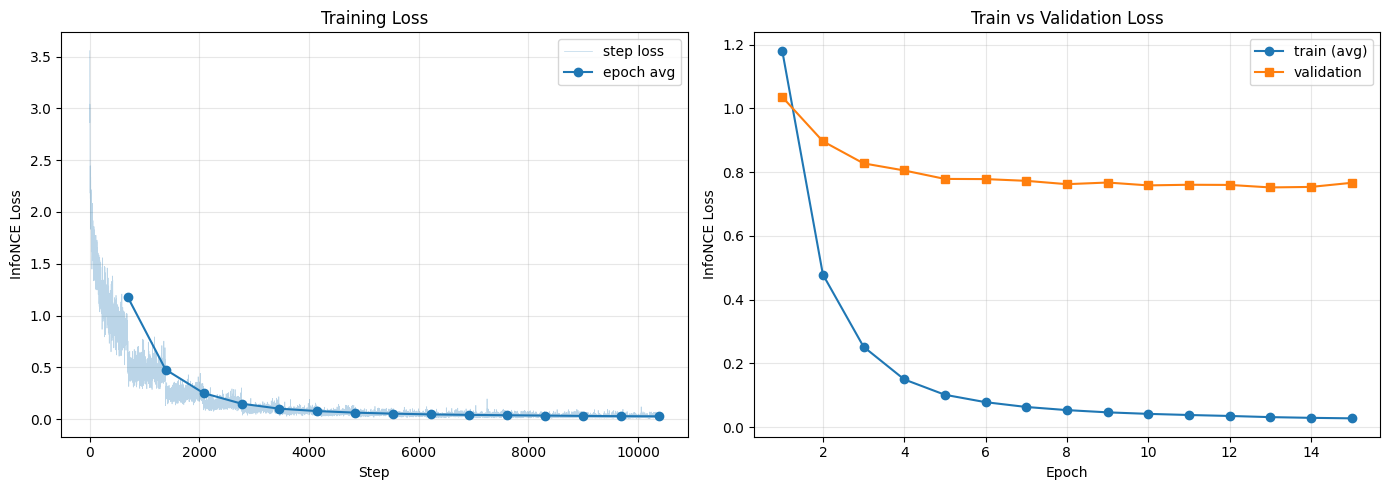

Saved: /Users/lukalodia/Desktop/NLP Project/Vector_Search_NLP/checkpoints/lstm_msmarco/loss_curves.png


In [8]:
import matplotlib.pyplot as plt

log_entries = [json.loads(line) for line in log_path.read_text().strip().split("\n")]

# Step-level train loss
steps = [e["step"] for e in log_entries if "train_loss" in e]
losses = [e["train_loss"] for e in log_entries if "train_loss" in e]

epoch_ends = [e for e in log_entries if e.get("event") == "epoch_end"]
epoch_steps = [e["step"] for e in epoch_ends]
epoch_train = [e["avg_train_loss"] for e in epoch_ends]
epoch_val = [e.get("val_loss") for e in epoch_ends]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: step-level train loss
axes[0].plot(steps, losses, alpha=0.3, linewidth=0.5, label="step loss")
axes[0].plot(epoch_steps, epoch_train, "o-", color="tab:blue", label="epoch avg")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("InfoNCE Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: epoch-level train vs val
epochs_x = list(range(1, len(epoch_ends) + 1))
axes[1].plot(epochs_x, epoch_train, "o-", label="train (avg)")
if any(v is not None for v in epoch_val):
    axes[1].plot(epochs_x, [v for v in epoch_val], "s-", label="validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("InfoNCE Loss")
axes[1].set_title("Train vs Validation Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "loss_curves.png", dpi=150)
plt.show()
print(f"Saved: {OUT_DIR / 'loss_curves.png'}")